<a href="https://colab.research.google.com/github/aabyyaann/Practical-Statistics-for-Data-Scientists/blob/main/Chapter06_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 — Statistical Machine Learning

## Tujuan Chapter

Pada chapter ini kita mempelajari beberapa algoritma machine learning yang paling populer dalam statistik dan data science.

Topik yang dipelajari:

1. Machine Learning Overview
2. Training and Testing Data
3. k-Nearest Neighbors (k-NN)
4. Decision Trees
5. Bagging
6. Random Forest
7. Feature Importance
8. Boosting
9. Cross Validation
10. Bias-Variance Tradeoff

Algoritma-algoritma ini banyak digunakan dalam dunia industri untuk prediksi dan klasifikasi.

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import accuracy_score

np.random.seed(42)

# Dataset Contoh

In [2]:
df = pd.DataFrame({
    "Age":[22,25,30,35,40,45,50,55,60,65],
    "Income":[25,30,35,40,50,55,60,65,75,85],
    "Purchased":[0,0,0,0,1,1,1,1,1,1]
})

df

,Age,Income,Purchased
0,22,25,0
1,25,30,0
2,30,35,0
3,35,40,0
4,40,50,1
5,45,55,1
6,50,60,1
7,55,65,1
8,60,75,1
9,65,85,1


# Memisahkan Feature dan Target

In [3]:
X = df[["Age","Income"]]

y = df["Purchased"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# 1. Machine Learning Workflow

Tahapan umum Machine Learning:

1. Data Collection
2. Data Cleaning
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. Prediction

# 2. k-Nearest Neighbors (k-NN)

k-NN mengklasifikasikan data berdasarkan tetangga terdekat.

In [5]:
knn = KNeighborsClassifier(
    n_neighbors=3
)

knn.fit(
    X_train,
    y_train
)

KNeighborsClassifier(n_neighbors=3)

# Prediksi k-NN

In [6]:
knn_pred = knn.predict(
    X_test
)

knn_pred

array([1, 0, 1])

In [7]:
knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print(knn_acc)

1.0


# Interpretasi

Accuracy menunjukkan persentase prediksi yang benar.

# Pengaruh Nilai k

Nilai k yang terlalu kecil dapat menyebabkan overfitting.

Nilai k yang terlalu besar dapat menyebabkan underfitting.

In [8]:
scores = []

for k in range(1,6):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    scores.append(
        accuracy_score(
            y_test,
            pred
        )
    )

scores

[1.0, 1.0, 1.0, 1.0, 1.0]

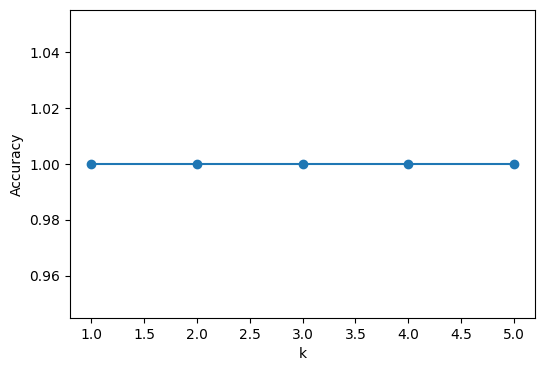

In [9]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,6),
    scores,
    marker='o'
)

plt.xlabel("k")
plt.ylabel("Accuracy")

plt.show()

# 3. Decision Tree

Decision Tree membuat aturan keputusan berbentuk pohon.

In [10]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

# Prediksi Decision Tree

In [11]:
tree_pred = tree_model.predict(
    X_test
)

tree_pred

array([1, 0, 1])

In [12]:
tree_acc = accuracy_score(
    y_test,
    tree_pred
)

print(tree_acc)

1.0


# Visualisasi Decision Tree

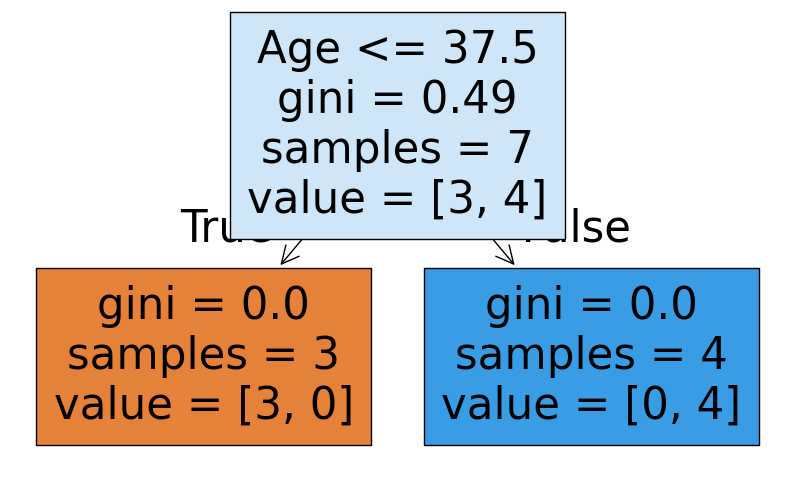

In [13]:
plt.figure(figsize=(10,6))

plot_tree(
    tree_model,
    filled=True,
    feature_names=["Age","Income"]
)

plt.show()

# Kelebihan Decision Tree

- Mudah dipahami
- Mudah divisualisasikan
- Tidak membutuhkan scaling

# Kekurangan Decision Tree

- Mudah overfit
- Sensitif terhadap perubahan data

In [14]:
print(
    "Bagging menggunakan konsep bootstrap yang dipelajari pada Chapter 2."
)

Bagging menggunakan konsep bootstrap yang dipelajari pada Chapter 2.


# 5. Random Forest

Random Forest adalah kumpulan banyak Decision Tree.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

# Prediksi Random Forest

In [16]:
rf_pred = rf_model.predict(
    X_test
)

rf_pred

array([1, 0, 1])

In [17]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(rf_acc)

1.0


# Perbandingan Model

In [18]:
comparison = pd.DataFrame({
    "Model":[
        "k-NN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        knn_acc,
        tree_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,k-NN,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


# 6. Feature Importance

Random Forest dapat menunjukkan fitur yang paling berpengaruh.

In [19]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
})

importance

,Feature,Importance
0,Age,0.489796
1,Income,0.510204


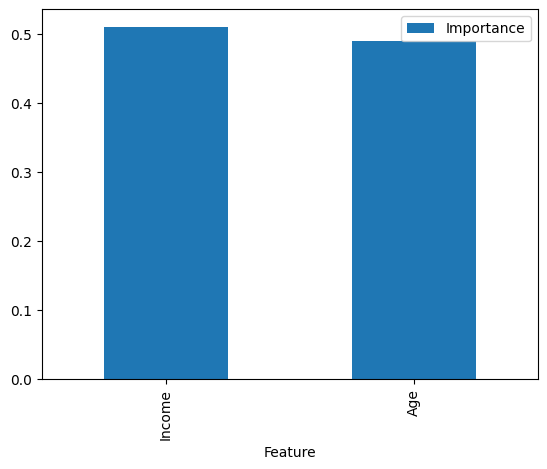

In [20]:
importance.sort_values(
    by="Importance",
    ascending=False
).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.show()

# Interpretasi

Semakin besar nilai importance maka semakin penting fitur tersebut.

# 7. Boosting

Boosting membangun model secara bertahap dengan memperbaiki kesalahan model sebelumnya.

In [21]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingClassifier(random_state=42)

# Prediksi Boosting

In [22]:
gb_pred = gb_model.predict(
    X_test
)

gb_pred

array([1, 0, 1])

In [23]:
gb_acc = accuracy_score(
    y_test,
    gb_pred
)

print(gb_acc)

1.0


# 8. Cross Validation

Cross Validation digunakan untuk mengevaluasi model secara lebih stabil.

In [24]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=3
)

cv_scores

array([0.75, 1.  , 1.  ])

In [25]:
print(
    cv_scores.mean()
)

0.9166666666666666


# Mengapa Cross Validation Penting?

Cross Validation membantu mengurangi ketergantungan pada satu pembagian data training-testing.

# 9. Bias-Variance Tradeoff

Bias:
- Model terlalu sederhana

Variance:
- Model terlalu kompleks

Tujuan Machine Learning adalah menemukan keseimbangan antara keduanya.

# Ringkasan Chapter 6

Pada chapter ini dipelajari:

- Machine Learning Workflow
- k-Nearest Neighbors (k-NN)
- Decision Tree
- Bagging
- Random Forest
- Feature Importance
- Boosting
- Cross Validation
- Bias-Variance Tradeoff

Model ensemble seperti Random Forest dan Boosting sering memberikan performa yang lebih baik dibanding model tunggal karena mampu mengurangi overfitting dan meningkatkan kemampuan generalisasi.

# Persiapan Chapter Berikutnya

Pada Chapter 7 kita akan mempelajari:

- Unsupervised Learning
- Clustering
- K-Means
- Hierarchical Clustering
- Principal Component Analysis (PCA)

yang digunakan ketika data tidak memiliki label.